In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
import os
from dotenv import load_dotenv
load_dotenv()
os.chdir(os.environ.get("DATASET_PATH"))

In [27]:
titanic = pd.read_csv('titanic_train.csv')
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [28]:
df = titanic.copy()

In [29]:
# Cabin and Age has null values 
# first we will handle the age column

df['Age'].isnull().sum()/len(df) *100  # 19 % data is missing 

np.float64(19.865319865319865)

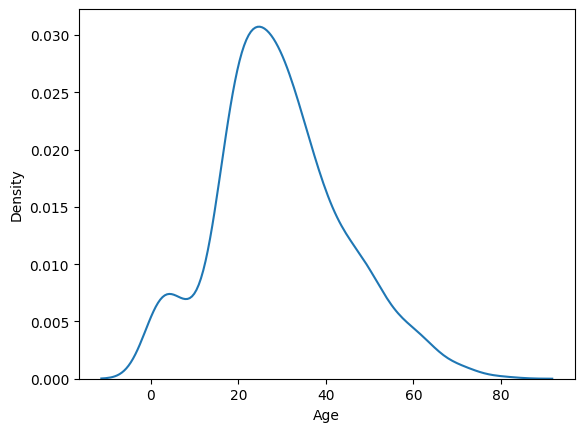

In [30]:
sns.kdeplot(data = df['Age'])
plt.show()

In [31]:
from sklearn.impute import SimpleImputer , KNNImputer
from sklearn.pipeline import Pipeline
# strategies = {
#     'mean_imputer' : SimpleImputer(strategy='mean').set_output(transform='pandas'),
#     'median_imputer' : SimpleImputer(strategy='median').set_output(transform='pandas'),
#     'knn_imputer' : KNNImputer().set_output(transform='pandas')        
# } 

# for name , imputer in strategies.items():
#     pipeline = Pipeline([(imputer)])
#     pipeline.fit(df)

In [ ]:
knn_imputer = KNNImputer()
op = knn_imputer.fit_transform(df['Age'].to_frame())
df['KnnAge'] = op.astype(int)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,KnnAge
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35


In [37]:
mean_imputer =  SimpleImputer(strategy='mean').set_output(transform='pandas')
op = mean_imputer.fit_transform(df['Age'].to_frame())
df['MeanAge'] = op.astype(int)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,KnnAge,MeanAge
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22,22
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38,38
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26,26
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35,35
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35,35


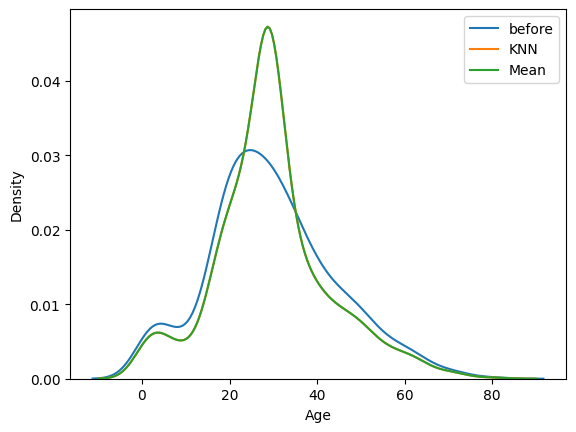

In [38]:
sns.kdeplot(data=df['Age'], label = 'before')
sns.kdeplot(data=df['KnnAge'], label = 'KNN')
sns.kdeplot(data=df['MeanAge'], label = 'Mean')

plt.legend()
plt.show()

<Axes: xlabel='count', ylabel='Density'>

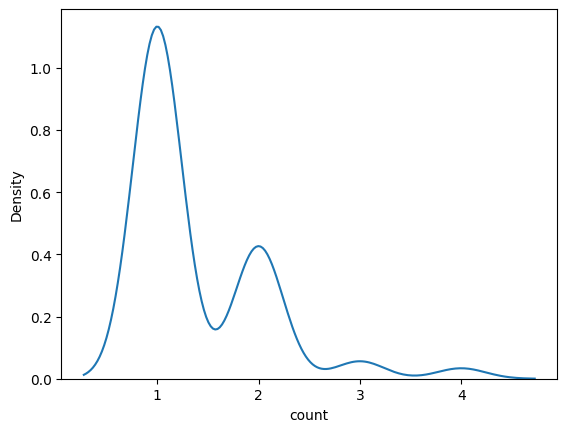

In [41]:
# cabin
sns.kdeplot(data=df['Cabin'].value_counts())